<a href="https://colab.research.google.com/github/AayushAswal27/movie-recommender-system/blob/main/movie_recommender.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [392]:
import pandas as pd
df=pd.read_csv("movies.csv")
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [393]:
df.shape

(4803, 20)

In [394]:
df.isnull().sum()

,0
budget,0
genres,0
homepage,3091
id,0
keywords,0
original_language,0
original_title,0
overview,3
popularity,0
production_companies,0


In [395]:
# Keep only the columns needed for recommendations and drop rows with missing values
df = df[['title', 'overview', 'genres', 'keywords']]
df.dropna(inplace=True)

In [396]:
df.shape

(4800, 4)

In [397]:
df.isnull().sum()

,0
title,0
overview,0
genres,0
keywords,0


In [398]:
df.iloc[0]['genres']

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

In [399]:
df.iloc[0]['keywords']

'[{"id": 1463, "name": "culture clash"}, {"id": 2964, "name": "future"}, {"id": 3386, "name": "space war"}, {"id": 3388, "name": "space colony"}, {"id": 3679, "name": "society"}, {"id": 3801, "name": "space travel"}, {"id": 9685, "name": "futuristic"}, {"id": 9840, "name": "romance"}, {"id": 9882, "name": "space"}, {"id": 9951, "name": "alien"}, {"id": 10148, "name": "tribe"}, {"id": 10158, "name": "alien planet"}, {"id": 10987, "name": "cgi"}, {"id": 11399, "name": "marine"}, {"id": 13065, "name": "soldier"}, {"id": 14643, "name": "battle"}, {"id": 14720, "name": "love affair"}, {"id": 165431, "name": "anti war"}, {"id": 193554, "name": "power relations"}, {"id": 206690, "name": "mind and soul"}, {"id": 209714, "name": "3d"}]'

In [400]:
type(df.iloc[0]['genres'])

str

In [401]:
type(df.iloc[0]['keywords'])

str

In [402]:
# Function to parse the string and extract only the 'name' from each dictionary
import ast
def extract_names(text):
    names = []
    for item in ast.literal_eval(text):
        names.append(item['name'])
    return names

In [403]:
# Convert genres and keywords from strings into clean lists of names
df['genres'] = df['genres'].apply(extract_names)
df['keywords'] = df['keywords'].apply(extract_names)

In [404]:
df['genres']

,genres
0,"[Action, Adventure, Fantasy, Science Fiction]"
1,"[Adventure, Fantasy, Action]"
2,"[Action, Adventure, Crime]"
3,"[Action, Crime, Drama, Thriller]"
4,"[Action, Adventure, Science Fiction]"
...,...
4798,"[Action, Crime, Thriller]"
4799,"[Comedy, Romance]"
4800,"[Comedy, Drama, Romance, TV Movie]"
4801,[]


In [405]:
df['keywords']

,keywords
0,"[culture clash, future, space war, space colon..."
1,"[ocean, drug abuse, exotic island, east india ..."
2,"[spy, based on novel, secret agent, sequel, mi..."
3,"[dc comics, crime fighter, terrorist, secret i..."
4,"[based on novel, mars, medallion, space travel..."
...,...
4798,"[united states–mexico barrier, legs, arms, pap..."
4799,[]
4800,"[date, love at first sight, narration, investi..."
4801,[]


In [406]:
# Function to remove spaces inside names so multi-word terms stay one token
def remove_spaces(word_list):
    return [word.replace(" ", "") for word in word_list]

In [407]:
df['genres'] = df['genres'].apply(remove_spaces)
df['keywords'] = df['keywords'].apply(remove_spaces)

In [408]:
df.head()

,title,overview,genres,keywords
0,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ..."
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad..."
2,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, basedonnovel, secretagent, sequel, mi6, ..."
3,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dccomics, crimefighter, terrorist, secretiden..."
4,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, ScienceFiction]","[basedonnovel, mars, medallion, spacetravel, p..."


In [409]:
df.iloc[0]['overview']

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.'

In [410]:
type(df.iloc[0]['overview'])

str

In [411]:
# Split overview into words, combine all text columns, then join into one lowercase tags string
df['overview'] = df['overview'].apply(lambda x: x.split())
df['tags'] = df['overview'] + df['genres'] + df['keywords']
df['tags'] = df['tags'].apply(lambda x: " ".join(x).lower())

In [412]:
df.iloc[0]['overview']

['In',
 'the',
 '22nd',
 'century,',
 'a',
 'paraplegic',
 'Marine',
 'is',
 'dispatched',
 'to',
 'the',
 'moon',
 'Pandora',
 'on',
 'a',
 'unique',
 'mission,',
 'but',
 'becomes',
 'torn',
 'between',
 'following',
 'orders',
 'and',
 'protecting',
 'an',
 'alien',
 'civilization.']

In [413]:
type(df.iloc[0]['overview'])

list

In [414]:
new_df = df[['title', 'tags']].reset_index(drop=True)

In [415]:
# Convert tags text into TF-IDF vectors (numbers), keeping top 5000 words
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
vectors = tfidf.fit_transform(new_df['tags']).toarray()

In [416]:
vectors.shape

(4800, 5000)

In [417]:
# Compute cosine similarity between every pair of movies
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(vectors)
similarity.shape

(4800, 4800)

In [418]:
# check the similarity score between two specific movies
def similarity_score(movie1, movie2):
    i = new_df[new_df['title'] == movie1].index[0]
    j = new_df[new_df['title'] == movie2].index[0]
    return similarity[i][j]

similarity_score('The Dark Knight Rises', 'Batman Begins')

np.float64(0.29766783777721395)

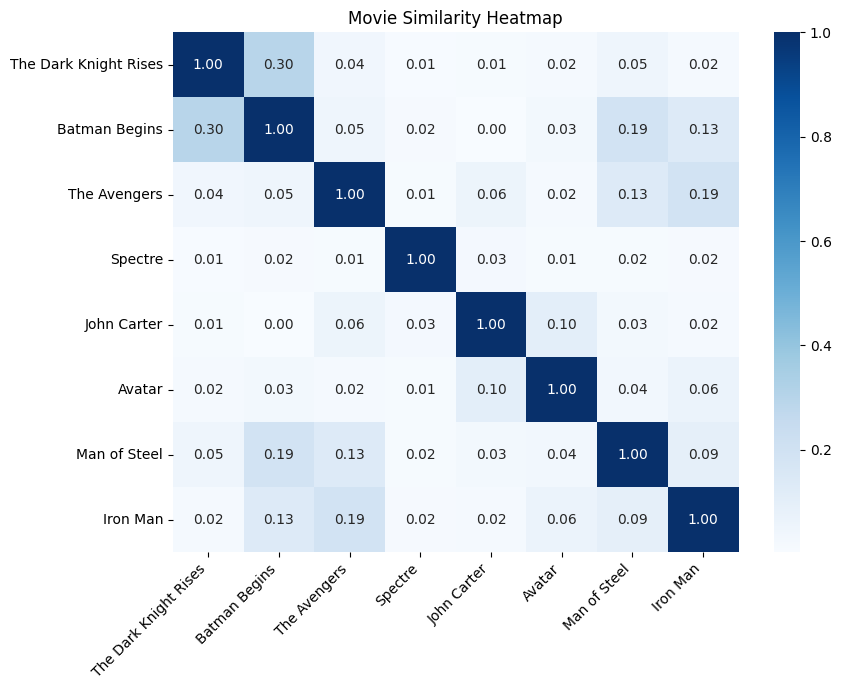

In [419]:
# Heatmap visualising similarity across a small sample of movies
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

movies = ['The Dark Knight Rises', 'Batman Begins', 'The Avengers',
          'Spectre', 'John Carter', 'Avatar', 'Man of Steel', 'Iron Man']

# get the index of each chosen movie
idx = [new_df[new_df['title'] == m].index[0] for m in movies]

# build the small similarity sub-matrix
sub = similarity[np.ix_(idx, idx)]

plt.figure(figsize=(9, 7))
sns.heatmap(sub, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=movies, yticklabels=movies)
plt.title('Movie Similarity Heatmap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [420]:
# Recommend top 5 movies most similar to the given title
def recommend(movie):
    index = new_df[new_df['title'] == movie].index[0]
    distances = sorted(
        list(enumerate(similarity[index])),
        reverse=True,
        key=lambda x: x[1]
    )
    for i in distances[1:6]:
        print(new_df.iloc[i[0]].title)

In [421]:
# Test recommendation for Avatar
recommend('Avatar')

Falcon Rising
Battle: Los Angeles
Apollo 18
Titan A.E.
Predators


In [422]:
# Test recommendation for The Dark Knight Rises
recommend('The Dark Knight Rises')

The Dark Knight
Batman Returns
Batman Forever
Batman
Batman Begins


In [423]:
# Test recommendation for John Carter
recommend('John Carter')

Mission to Mars
Red Planet
Ghosts of Mars
Get Carter
The Martian


In [424]:
# Test recommendation for The Avengers
recommend('The Avengers')

Avengers: Age of Ultron
Ant-Man
Captain America: The First Avenger
Thor: The Dark World
Iron Man 3
